# 3. PyTEM: Backends and Hardware Acceleration

Even with the analytical Jacobian, the NumPy implementation still spends most of its time in Python loops: one iteration of the time loop per gate, with vectorised NumPy operations inside. Two compiled backends can push this further:

| Backend | How to enable | What it does |
|---------|---------------|--------------|
| **NumPy** (default) | — | Pure Python with vectorised array ops; works on any machine |
| **Numba JIT** | `use_numba=True` | Compiles the recursion loops to native machine code at first call; typically 5–20× faster than NumPy on CPU |
| **CuPy (GPU)** | `use_cuda=True` | Runs the entire forward+backward pass as GPU kernels; requires an NVIDIA GPU with CUDA; fastest option for large problems |

---

### What is Numba?

[Numba](https://numba.readthedocs.io) is a **Just-In-Time (JIT) compiler** for Python. It translates ordinary Python functions decorated with `@numba.jit` (or `@numba.njit`) into optimised native machine code at the first time they are called — a process called JIT compilation. After the first call, subsequent calls run at speeds comparable to compiled C or Fortran, with no Python interpreter overhead.

Numba is especially effective for code that contains explicit loops over arrays, which is exactly the pattern in the upward recursion used to compute the Jacobian. It works on any modern CPU and requires no specialised hardware.

**Installation:**
```
pip install numba
```
or with conda:
```
conda install -c conda-forge numba
```
Numba requires LLVM under the hood, but `pip`/`conda` handle that automatically. After installing, check it works with:
```python
import numba
print(numba.__version__)
```

---

### What is CUDA / CuPy?

**CUDA** (Compute Unified Device Architecture) is NVIDIA's parallel computing platform and programming model. It lets you run thousands of threads simultaneously on the cores of an NVIDIA GPU, which can be orders of magnitude faster than a CPU for embarrassingly parallel workloads.

[CuPy](https://cupy.dev) is a NumPy-compatible array library that runs on NVIDIA GPUs via CUDA. pyTEM uses CuPy to offload the entire forward+backward pass to the GPU: each gate time and each layer can be evaluated in parallel, so the Jacobian computation scales almost linearly with the number of GPU cores available.

**Requirements:**
- An NVIDIA GPU (any CUDA-capable card, e.g. GTX 10-series or newer)
- The NVIDIA CUDA Toolkit (version must match your CuPy build)

**Installation** (pick the version matching your CUDA toolkit):
```
pip install cupy-cuda11x   # for CUDA 11.x
pip install cupy-cuda12x   # for CUDA 12.x
```
or with conda:
```
conda install -c conda-forge cupy
```
Check your CUDA version first with `nvidia-smi` in a terminal. After installing, verify with:
```python
import cupy
print(cupy.__version__)
print(cupy.cuda.runtime.runtimeGetVersion())
```

---

The cells below define the Numba and CuPy kernels. Both implement exactly the same adjoint upward recursion as the NumPy version — only the execution model differs. Timing comparisons across all three backends are shown at the end of this section.


## How to run

- **Requirements:** Python 3.11+ with `numpy`, `scipy`, and `matplotlib`; optionally `numba` (CPU) and `cupy` (GPU) for the accelerated backends. You also need the **`pytem` package from this repository**.
- **Paths:** the import cell locates `pytem` automatically by searching upward from the working directory, so there are no absolute paths to edit. (Alternatively, run `pip install -e .` from the repository root.)
- Run the cells **top to bottom**.


In [1]:
import sys
import time
import importlib
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Locate the pyTEM repo root (the folder containing the `pytem` package) by
# searching upward from the working directory, so no absolute path is needed.
for _root in [Path.cwd(), *Path.cwd().parents]:
    if (_root / "pytem").is_dir():
        if str(_root) not in sys.path:
            sys.path.insert(0, str(_root))
        break


from pytem import (
    fwd_circle_central,
    fwd_circle_offset,
    fwd_square_central,
    fwd_square_offset,
    getR,
    MU0,
    HANKEL_FILTERS,
    FOURIER_FILTERS,
    EULER_PARAMS,
    HAS_NUMBA,
    HAS_CUDA,
    getJ_ana,
    getJ_fd
)
# ==============================================================================
# Numba JIT + GPU kernels live in pytem.kernels_jacobian.
# ==============================================================================

if HAS_NUMBA:
    from pytem.kernels_jacobian import (
        _te_rte_grad_jit,
        _tem_circular_grad_jit, _tem_square_grad_jit,
        _tem_circular_grad_euler_jit, _tem_square_grad_euler_jit,
    )
    print("Numba JIT kernels loaded from pytem.kernels_jacobian")

if HAS_CUDA:
    from pytem.kernels_jacobian import (
        _te_reflection_coeff_grad_gpu,
        _tem_circular_grad_gpu, _tem_square_grad_gpu,
        _tem_circular_grad_euler_gpu, _tem_square_grad_euler_gpu,
    )
    print("GPU kernels loaded from pytem.kernels_jacobian")

# Confirm the dispatcher is available
import inspect
print("getJ_ana params:", list(inspect.signature(getJ_ana).parameters.keys()))

# --- Benchmark model: 30 layers, 31 gate times ---
# Same depths, gate count, and loop geometry as the actual inversion so the
# timing numbers reflect the true per-call cost.
depths        = np.cumsum(np.geomspace(1.0, 12.0, 30))   # 30 cumulative depths [m]
thicknesses   = np.diff(depths)                            # 29 thicknesses
resistivities = np.ones(len(depths)) * 100.0               # 30 resistivities [Ohm.m]
a             = np.sqrt(50.**2 / np.pi)                    # equivalent circle radius [m]
L             = np.sqrt(np.pi) * a                         # equal-area square side [m]
rx_offset     = 10.0                                       # offset receiver [m]
times         = np.logspace(-5, -2, 31)                    # 31 log-spaced gates [s]
log_resistivities = np.log(resistivities)

Numba JIT kernels loaded from pytem.kernels_jacobian
GPU kernels loaded from pytem.kernels_jacobian
getJ_ana params: ['thicknesses', 'log_resistivities', 'tx_size', 'times', 'geometry', 'rx_x', 'rx_y', 'n_quad', 'use_symmetry', 'use_numba', 'use_cuda', 'system_filter', 'tx_height', 'rx_height', 'transform', 'hankel_filter', 'fourier_filter', 'euler_order', 'jacobian_mode']


In [2]:

# ============================================================
# CONFIGURATION — swap the forward model used for J timing
# ============================================================
# Set _fwd_model to any of the four options below, then re-run
# this cell and the timing cell that follows.
#
# Wrapper functions translate getJ's unified calling convention
#   fwd(thicknesses, resistivities, tx_radius, times, **kw)
# to each geometry's specific parameter signature.

_rx_offset = 10.0   # receiver offset [m]  — offset variants
_n_quad    = 5      # quadrature order      — square variants

def _wrap_circle_offset(thicknesses, resistivities, tx_radius, times, **kw):
    return fwd_circle_offset(thicknesses, resistivities, tx_radius, _rx_offset, times, **kw)

def _wrap_square_central(thicknesses, resistivities, tx_radius, times, **kw):
    # tem_forward_square supports use_numba, use_cuda, euler_order, transform, etc.
    return fwd_square_central(thicknesses, resistivities, tx_radius * np.sqrt(np.pi),
                              times, n_quad=_n_quad, **kw)

def _wrap_square_offset(thicknesses, resistivities, tx_radius, times, **kw):
    return fwd_square_offset(thicknesses, resistivities, tx_radius * np.sqrt(np.pi),
                             _rx_offset, 0.0, times, n_quad=_n_quad, **kw)

# ---- Change this line to switch model ----
_fwd_model = fwd_circle_central
#_fwd_model = _wrap_circle_offset
#_fwd_model = _wrap_square_central
# _fwd_model = _wrap_square_offset

_fwd_label = {
    fwd_circle_central:   'Circle (central)',
    _wrap_circle_offset:  f'Circle (offset  rx={_rx_offset} m)',
    _wrap_square_central: f'Square (central  n_quad={_n_quad})',
    _wrap_square_offset:  f'Square (offset  rx={_rx_offset} m  n_quad={_n_quad})',
}.get(_fwd_model, getattr(_fwd_model, '__name__', str(_fwd_model)))

# Map each forward model to the geometry string and kwargs for getJ_ana.
_geometry_for_ana = {
    fwd_circle_central:   ('circle_central',  {}),
    _wrap_circle_offset:  ('circle_offset',   {'rx_x': _rx_offset}),
    _wrap_square_central: ('square_central',  {'n_quad': _n_quad}),
    _wrap_square_offset:  ('square_offset',   {'rx_x': _rx_offset, 'n_quad': _n_quad}),
}
_geometry, _ana_kwargs = _geometry_for_ana.get(_fwd_model, ('circle_central', {}))

_ana_available = True   # all four geometries support the analytical Jacobian

print(f"Forward model selected : {_fwd_label}")
print(f"Geometry key           : {_geometry}")
print(f"Analytical Jacobian    : available for all geometries")


Forward model selected : Circle (central)
Geometry key           : circle_central
Analytical Jacobian    : available for all geometries


In [3]:
import timeit
def benchmark(fn, n=3):
    """Median wall-time [s] over n repeated single runs."""
    return np.median(timeit.repeat(fn, number=1, repeat=n))

from pytem.inversion import getJ_fd, getJ_ana

# getJ_fd drives the forward wrapper (which converts the equivalent radius a to
# the square side internally), so it takes tx_size=a.  getJ_ana works from the
# geometry string directly and expects the literal Tx dimension: a for circle,
# the square side L for square geometries.
_tx_ana = L if _geometry.startswith('square') else a

# ---- accuracy check: Ana NumPy DLF vs FD NumPy DLF -------------------------
_jcfg_dlf   = dict(hankel_filter='key_101', fourier_filter='key_81',  transform='dlf')
_jcfg_euler = dict(hankel_filter='key_101', euler_order=11,            transform='euler')

print(f"Accuracy check ({_fwd_label}) ...")
J_fd_ref = getJ_fd(thicknesses=thicknesses, log_resistivities=log_resistivities,
                tx_size=a, times=times, fwd=_fwd_model,
                use_numba=False, use_cuda=False, **_jcfg_dlf)

J_ana_ref = getJ_ana(thicknesses=thicknesses, log_resistivities=log_resistivities,
                             tx_size=_tx_ana, times=times, geometry=_geometry,
                             use_numba=False, use_cuda=False,
                             **_ana_kwargs, **_jcfg_dlf)

denom = np.abs(J_fd_ref)
denom[denom < 1e-30] = 1e-30
rel_err = np.abs(J_ana_ref - J_fd_ref) / denom
print(f"  Ana NumPy DLF vs FD NumPy DLF  max rel. error = {rel_err.max():.2e}  "
      f"mean (non-zero) = {rel_err[np.abs(J_fd_ref) > 1e-10].mean():.2e}")

# ---- timing -----------------------------------------------------------------
# Keys are (method, transform, backend) tuples so no backslash in f-strings.
# method: 'FD' or 'Ana'  |  transform: 'DLF' or 'Euler'  |  backend: 'NumPy','Numba','CUDA'

timing = {}   # (method, transform, backend) -> seconds

# NumPy baselines
print("\nTiming NumPy baselines ...")
timing[('FD',  'DLF',   'NumPy')] = benchmark(lambda: getJ_fd(
    thicknesses=thicknesses, log_resistivities=log_resistivities,
    tx_size=a, times=times, fwd=_fwd_model,
    use_numba=False, use_cuda=False, **_jcfg_dlf))

timing[('FD',  'Euler', 'NumPy')] = benchmark(lambda: getJ_fd(
    thicknesses=thicknesses, log_resistivities=log_resistivities,
    tx_size=a, times=times, fwd=_fwd_model,
    use_numba=False, use_cuda=False, **_jcfg_euler))

timing[('Analytical', 'DLF',   'NumPy')] = benchmark(lambda: getJ_ana(
    thicknesses=thicknesses, log_resistivities=log_resistivities,
    tx_size=_tx_ana, times=times, geometry=_geometry,
    use_numba=False, use_cuda=False, **_ana_kwargs, **_jcfg_dlf))

timing[('Analytical', 'Euler', 'NumPy')] = benchmark(lambda: getJ_ana(
    thicknesses=thicknesses, log_resistivities=log_resistivities,
    tx_size=_tx_ana, times=times, geometry=_geometry,
    use_numba=False, use_cuda=False, **_ana_kwargs, **_jcfg_euler))

for (m, tr, be), v in timing.items():
    print(f"  {m:3s} {tr:5s} {be:5s}: {v*1000:.1f} ms")

# Numba (warm up first so JIT cost is excluded)
if HAS_NUMBA:
    print("\nWarming up Numba ...")
    getJ_fd(thicknesses=thicknesses, log_resistivities=log_resistivities,
         tx_size=a, times=times, fwd=_fwd_model,
         use_numba=True, use_cuda=False, **_jcfg_dlf)
    getJ_ana(thicknesses=thicknesses, log_resistivities=log_resistivities,
                    tx_size=_tx_ana, times=times, geometry=_geometry,
                    use_numba=True, use_cuda=False, **_ana_kwargs, **_jcfg_dlf)
    print("Timing Numba ...")
    timing[('FD',  'DLF',   'Numba')] = benchmark(lambda: getJ_fd(
        thicknesses=thicknesses, log_resistivities=log_resistivities,
        tx_size=a, times=times, fwd=_fwd_model,
        use_numba=True, use_cuda=False, **_jcfg_dlf))
    timing[('FD',  'Euler', 'Numba')] = benchmark(lambda: getJ_fd(
        thicknesses=thicknesses, log_resistivities=log_resistivities,
        tx_size=a, times=times, fwd=_fwd_model,
        use_numba=True, use_cuda=False, **_jcfg_euler))
    timing[('Analytical', 'DLF',   'Numba')] = benchmark(lambda: getJ_ana(
        thicknesses=thicknesses, log_resistivities=log_resistivities,
        tx_size=_tx_ana, times=times, geometry=_geometry,
        use_numba=True, use_cuda=False, **_ana_kwargs, **_jcfg_dlf))
    timing[('Analytical', 'Euler', 'Numba')] = benchmark(lambda: getJ_ana(
        thicknesses=thicknesses, log_resistivities=log_resistivities,
        tx_size=_tx_ana, times=times, geometry=_geometry,
        use_numba=True, use_cuda=False, **_ana_kwargs, **_jcfg_euler))
    for k in [('FD', 'DLF', 'Numba'), ('FD', 'Euler', 'Numba'),
              ('Analytical', 'DLF', 'Numba'), ('Analytical', 'Euler', 'Numba')]:
        m, tr, be = k
        print(f"  {m:3s} {tr:5s} {be:5s}: {timing[k]*1000:.1f} ms")

# CUDA
if HAS_CUDA:
    print("\nWarming up CUDA ...")
    getJ_fd(thicknesses=thicknesses, log_resistivities=log_resistivities,
         tx_size=a, times=times, fwd=_fwd_model,
         use_numba=False, use_cuda=True, **_jcfg_dlf)
    getJ_ana(thicknesses=thicknesses, log_resistivities=log_resistivities,
                    tx_size=_tx_ana, times=times, geometry=_geometry,
                    use_numba=False, use_cuda=True, **_ana_kwargs, **_jcfg_dlf)
    print("Timing CUDA ...")
    timing[('FD',  'DLF',   'CUDA')] = benchmark(lambda: getJ_fd(
        thicknesses=thicknesses, log_resistivities=log_resistivities,
        tx_size=a, times=times, fwd=_fwd_model,
        use_numba=False, use_cuda=True, **_jcfg_dlf))
    timing[('FD',  'Euler', 'CUDA')] = benchmark(lambda: getJ_fd(
        thicknesses=thicknesses, log_resistivities=log_resistivities,
        tx_size=a, times=times, fwd=_fwd_model,
        use_numba=False, use_cuda=True, **_jcfg_euler))
    timing[('Analytical', 'DLF',   'CUDA')] = benchmark(lambda: getJ_ana(
        thicknesses=thicknesses, log_resistivities=log_resistivities,
        tx_size=_tx_ana, times=times, geometry=_geometry,
        use_numba=False, use_cuda=True, **_ana_kwargs, **_jcfg_dlf))
    timing[('Analytical', 'Euler', 'CUDA')] = benchmark(lambda: getJ_ana(
        thicknesses=thicknesses, log_resistivities=log_resistivities,
        tx_size=_tx_ana, times=times, geometry=_geometry,
        use_numba=False, use_cuda=True, **_ana_kwargs, **_jcfg_euler))
    for k in [('FD', 'DLF', 'CUDA'), ('FD', 'Euler', 'CUDA'),
              ('Analytical', 'DLF', 'CUDA'), ('Analytical', 'Euler', 'CUDA')]:
        m, tr, be = k
        print(f"  {m:3s} {tr:5s} {be:5s}: {timing[k]*1000:.1f} ms")


Accuracy check (Circle (central)) ...
  Ana NumPy DLF vs FD NumPy DLF  max rel. error = 4.46e-02  mean (non-zero) = 2.74e-04

Timing NumPy baselines ...
  FD  DLF   NumPy: 95600.1 ms
  FD  Euler NumPy: 46870.5 ms
  Analytical DLF   NumPy: 4822.3 ms
  Analytical Euler NumPy: 1303.8 ms

Warming up Numba ...
Timing Numba ...
  FD  DLF   Numba: 29451.2 ms
  FD  Euler Numba: 15190.0 ms
  Analytical DLF   Numba: 4012.1 ms
  Analytical Euler Numba: 1158.4 ms

Warming up CUDA ...
Timing CUDA ...
  FD  DLF   CUDA : 4380.2 ms
  FD  Euler CUDA : 2177.6 ms
  Analytical DLF   CUDA : 339.0 ms
  Analytical Euler CUDA : 216.9 ms


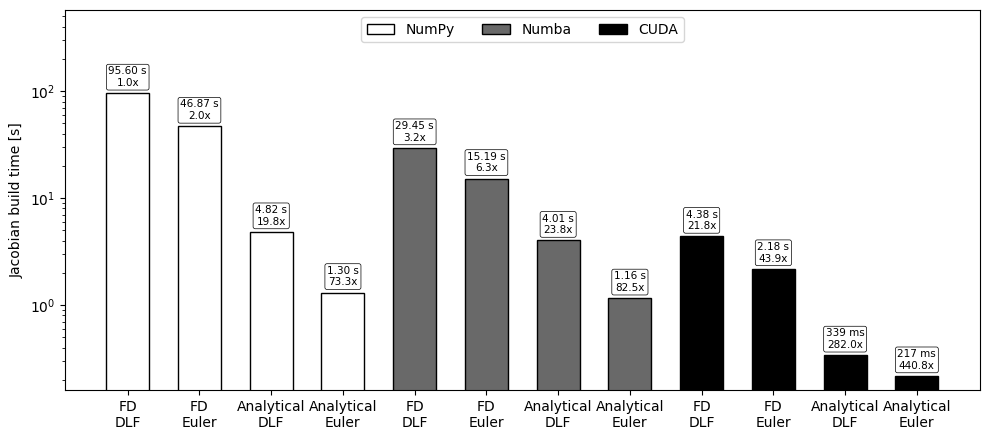

In [4]:
from matplotlib import patches
_colour_map = {'NumPy': 'white', 'Numba': 'dimgray', 'CUDA': 'black'}

keys       = list(timing.keys())
vals       = [timing[k] for k in keys]
tick_labels = [k[0] + '\n' + k[1] for k in keys]
colours     = [_colour_map[k[2]] for k in keys]
x           = np.arange(len(keys))

ref = timing[('FD', 'DLF', 'NumPy')]

fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.bar(x, vals, color=colours, edgecolor='black', width=0.6)
for bar, val in zip(bars, vals):
    speedup = ref / val
    time_label = f"{val:.2f} s" if val >= 0.5 else f"{val*1000:.0f} ms"
    ax.text(bar.get_x() + bar.get_width() / 2, val * 1.12,
            f"{time_label}\n{speedup:.1f}x",
            ha='center', va='bottom', fontsize=7.5,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                      edgecolor='black', lw=0.5))

ax.set_xticks(x)
ax.set_xticklabels(tick_labels)

legend_handles = [
    patches.Patch(facecolor='white',   edgecolor='black', label='NumPy'),
    patches.Patch(facecolor='dimgray', edgecolor='black', label='Numba'),
    patches.Patch(facecolor='black',   edgecolor='black', label='CUDA'),
]
ax.legend(handles=legend_handles, ncol=3, loc='upper center')
ax.set_ylabel('Jacobian build time [s]')
ax.set_yscale('log')
ax.set_ylim(None, np.ceil(max(vals) * 6))
fig.tight_layout()
plt.show()
